Ogive generating radius ρ = 24.03 m
Ogive arc length          = 14.95 m
Total arc length (+ skirt)= 20.45 m
Total height              = 19.5 m


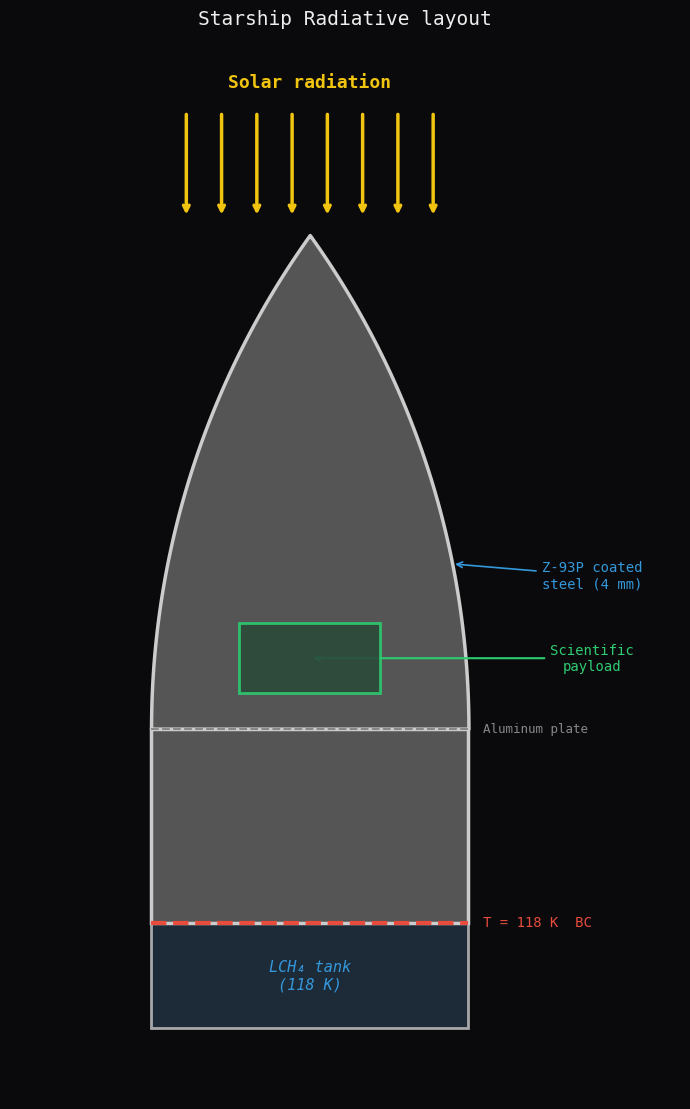

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, trapezoid
from scipy.interpolate import interp1d

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

# ═══════════════════════════════════════════════════
#  Constants & geometry
# ═══════════════════════════════════════════════════
sigma = 5.670374419e-8   # Stefan-Boltzmann, W/m²/K⁴
S0    = 1361.0            # Solar irradiance at 1 AU, W/m²
alpha = 0.16        # Z-93P absorptance
eps   = 0.921             # Z-93P emittance
k     = 15.0              # 304L steel conductivity, W/m/K
t     = 0.004             # Shell thickness, m

h_nose  = 14.0            # Ogive nosecone height, m
R       = 4.5             # Base radius, m
h_skirt = 5.5             # Vertical skirt height, m
T_tank  = 118.0           # LCH4 tank top boundary, K

# Tangent ogive generating radius
rho = (R**2 + h_nose**2) / (2 * R)

# ─── Ogive profile: z from tip (h_nose) to base (0) ───
N_og   = 20000
z_og   = np.linspace(h_nose, 0, N_og)
r_og   = np.sqrt(rho**2 - z_og**2) - (rho - R)
r_og   = np.maximum(r_og, 0.0)

# Arc length along ogive (tip → base)
dsdz_og  = rho / np.sqrt(rho**2 - z_og**2)
ds_og    = np.abs(np.diff(z_og)) * 0.5 * (dsdz_og[:-1] + dsdz_og[1:])
s_og     = np.concatenate([[0], np.cumsum(ds_og)])
S_ogive  = s_og[-1]

# Solar flux on ogive: α·S₀·cos(θ), cos(θ) = z/ρ
q_og    = alpha * S0 * np.maximum(z_og / rho, 0.0)
drds_og = z_og / rho

# ─── Skirt: vertical cylinder, r = R, no solar flux ───
N_sk    = 5000
s_sk_l  = np.linspace(0, h_skirt, N_sk)
z_sk    = -s_sk_l                     # z goes below 0
r_sk    = np.full(N_sk, R)
q_sk    = np.zeros(N_sk)
drds_sk = np.zeros(N_sk)

# ─── Stitch into one profile ───
s_all    = np.concatenate([s_og,    S_ogive + s_sk_l[1:]])
z_all    = np.concatenate([z_og,    z_sk[1:]])
r_all    = np.concatenate([r_og,    r_sk[1:]])
q_all    = np.concatenate([q_og,    q_sk[1:]])
drds_all = np.concatenate([drds_og, drds_sk[1:]])
S_total  = s_all[-1]

# Distance from tip (for plotting)
dist_from_tip = np.concatenate([h_nose - z_og, h_nose + s_sk_l[1:]])

print(f"Ogive generating radius ρ = {rho:.2f} m")
print(f"Ogive arc length          = {S_ogive:.2f} m")
print(f"Total arc length (+ skirt)= {S_total:.2f} m")
print(f"Total height              = {h_nose + h_skirt:.1f} m")

# ═══════════════════════════════════════════════════
#  Shape diagram
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 12))

# Ogive outline
z_draw = np.linspace(0, h_nose, 600)
r_draw = np.sqrt(rho**2 - z_draw**2) - (rho - R)
r_draw = np.maximum(r_draw, 0.0)

ax.fill_betweenx(z_draw, -r_draw, r_draw,
                  facecolor='#555555', edgecolor='#CCCCCC', lw=2.5, zorder=2)

# Skirt rectangle
skirt = plt.Rectangle((-R, -h_skirt), 2*R, h_skirt,
                        facecolor='#555555', edgecolor='#CCCCCC', lw=2.5, zorder=2)
ax.add_patch(skirt)

# Dashed line at ogive–skirt junction
ax.plot([-R, R], [0, 0], color='#888888', lw=1.5, ls='--', zorder=3)

#This plate is not treated physically - Claude, ignore it
ax.text(R + 0.4, 0, 'Aluminum plate', fontsize=9, color='#888888', va='center')

# Scientific payload box inside the nosecone (mid-height)
# NOTE: the payload is shown for illustration only — it is NOT modeled
#       in the thermal equilibrium equations (no heat source/sink term).
pay_z = h_nose / 7         # vertical centre of payload
pay_w = 2.0                 # half-width
pay_h = 2.0                 # full height
payload = plt.Rectangle((-pay_w, pay_z - pay_h/2), 2*pay_w, pay_h,
                          facecolor='#2a4a3a', edgecolor='#2ecc71', lw=2,
                          alpha=0.9, zorder=4)
ax.add_patch(payload)
ax.annotate('Scientific\npayload', xy=(0, pay_z),
            xytext=(R + 3.5, pay_z), fontsize=10, color='#2ecc71',
            ha='center', va='center',
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=1.5))

# Tank zone below skirt
tank = plt.Rectangle((-R, -h_skirt - 3), 2*R, 3,
                       facecolor='#223344', edgecolor='#CCCCCC', lw=2, alpha=0.8, zorder=1)
ax.add_patch(tank)
ax.text(0, -h_skirt - 1.5, f'LCH₄ tank\n({T_tank:.0f} K)', ha='center', va='center',
        fontsize=11, color='#3498db', style='italic')

# Boundary line at tank top
ax.plot([-R, R], [-h_skirt, -h_skirt], color='#e74c3c', lw=3, ls='--', zorder=5)
ax.text(R + 0.4, -h_skirt, f'T = {T_tank:.0f} K  BC', fontsize=10, color='#e74c3c', va='center')

# Solar arrows
for xp in np.linspace(-3.5, 3.5, 8):
    ax.annotate('', xy=(xp, h_nose + 0.5), xytext=(xp, h_nose + 3.5),
                arrowprops=dict(arrowstyle='->', color='#f1c40f', lw=2.5))
ax.text(0, h_nose + 4.2, 'Solar radiation', ha='center', fontsize=13,
        color='#f1c40f', fontweight='bold')

# # Dimension annotations
# ax.annotate('', xy=(-R - 1.5, 0), xytext=(-R - 1.5, h_nose),
#             arrowprops=dict(arrowstyle='<->', color='#CCCCCC', lw=1.5))
# ax.text(-R - 2.0, h_nose / 2, f'{h_nose:.0f} m', fontsize=10, color='#CCCCCC',
#         ha='center', va='center', rotation=90)

# ax.annotate('', xy=(-R - 1.5, -h_skirt), xytext=(-R - 1.5, 0),
#             arrowprops=dict(arrowstyle='<->', color='#CCCCCC', lw=1.5))
# ax.text(-R - 2.0, -h_skirt / 2, f'{h_skirt:.1f} m', fontsize=10, color='#CCCCCC',
#         ha='center', va='center', rotation=90)

# ax.annotate('', xy=(-R, -h_skirt - 3.6), xytext=(R, -h_skirt - 3.6),
#             arrowprops=dict(arrowstyle='<->', color='#CCCCCC', lw=1.5))
# ax.text(0, -h_skirt - 4.2, f'⌀ {2*R:.0f} m', fontsize=10, color='#CCCCCC', ha='center')

# Labels
idx = len(z_draw) // 3
ax.annotate('Z-93P coated\nsteel (4 mm)', xy=(r_draw[idx], z_draw[idx]),
            xytext=(R + 3.5, h_nose * 0.5 - 3), fontsize=10, color='#3498db',
            ha='center', arrowprops=dict(arrowstyle='->', color='#3498db', lw=1.2))

ax.set_xlim(-R - 4, R + 6)
ax.set_ylim(-h_skirt - 5, h_nose + 5.5)
ax.set_aspect('equal')
ax.set_title('Starship Radiative layout', fontsize=14, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

Solver: converged  (5155 nodes)

──────────────────────────────────────────────────
  Solar power absorbed:             13853.2 W
  Power radiated (outer side):      14003.2 W
  Heat drawn from tank by skirt:      150.0 W
  Balance (in − out):                  -0.0 W
──────────────────────────────────────────────────
  Tip temperature:  221.2 K
  Min temperature:  52.8 K  (at h = 16.4 m from tip)
  Ogive base (h=14.0m): 78.2 K


/tmp/ipykernel_8535/3991170547.py:83: RuntimeWarning: invalid value encountered in power
  T_eq = np.where(qf > 0, (qf / (eps*sigma))**0.25, 0)


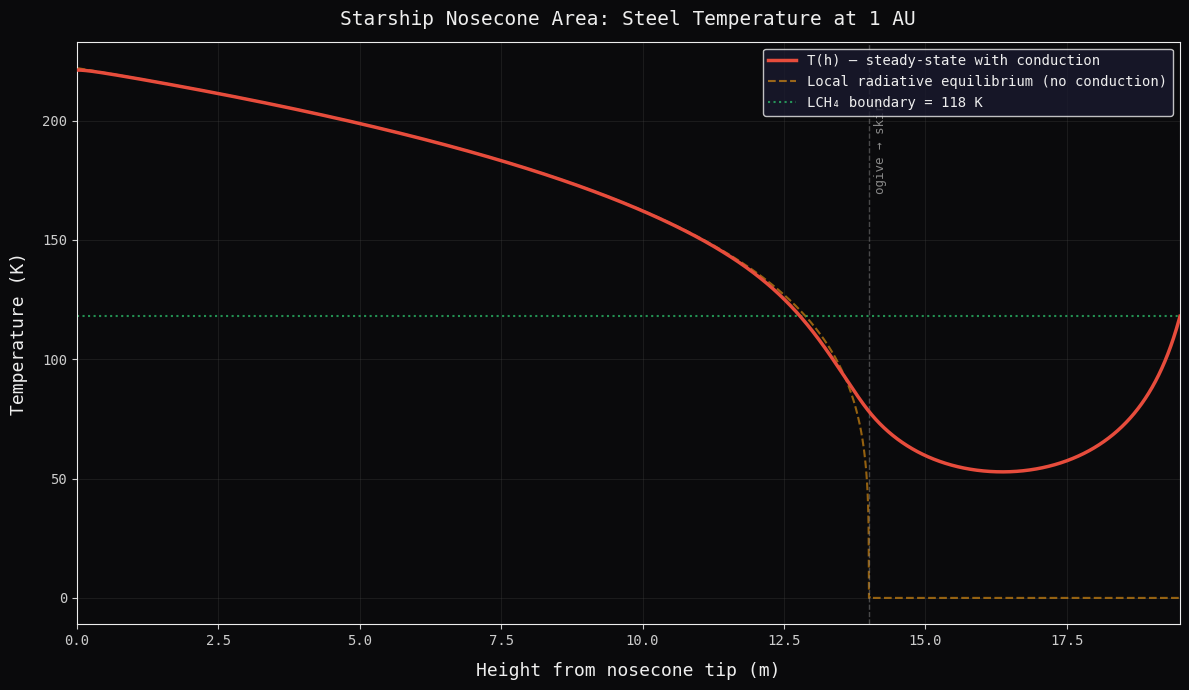

In [3]:
# ═══════════════════════════════════════════════════
#  Solve steady-state heat equation on ogive + skirt
# ═══════════════════════════════════════════════════
# On a thin axisymmetric shell, energy balance on a ring element ds:
#
#   d/ds[k·t·r(s)·dT/ds] + [q(s) − ε σ T⁴] r(s) = 0
#
# Expanding:  k·t·r·T'' + k·t·(dr/ds)·T' + [q(s) − εσT⁴]·r = 0
#
#   T'' = [εσT⁴ − q(s)] / (k·t)  −  (dr/ds)/r · T'
#
# BCs:  T'(0)      = 0       (insulated tip)
#       T(S_total)  = T_tank  (LCH4 boundary)
#
# Only the outer surface radiates to space; inner-surface radiation is ignored.

# Interpolation functions over combined arc length
r_fn    = interp1d(s_all, r_all,    kind='cubic', fill_value='extrapolate')
q_fn    = interp1d(s_all, q_all,    kind='cubic', fill_value='extrapolate')
drds_fn = interp1d(s_all, drds_all, kind='cubic', fill_value='extrapolate')
dist_fn = interp1d(s_all, dist_from_tip, kind='cubic', fill_value='extrapolate')

s0 = 0.02  # small offset from tip to avoid 1/r singularity

def ode(s, y):
    T, dT = y
    T  = np.maximum(T, 1.0)
    rv = np.maximum(r_fn(s), 1e-4)
    d2T = (eps*sigma*T**4 - q_fn(s)) / (k*t) - drds_fn(s)/rv * dT
    return np.vstack([dT, d2T])

def bc(ya, yb):
    return np.array([ya[1],             # dT/ds = 0 at tip
                     yb[0] - T_tank])   # T = T_tank at tank

# Initial guess: local radiative equilibrium, clamped to T_tank
N_bvp  = 3000
s_mesh = np.linspace(s0, S_total, N_bvp)
q_guess = np.maximum(q_fn(s_mesh), 0.0)
T_loc  = np.where(q_guess > 0,
                   (q_guess / (eps*sigma))**0.25,
                   T_tank)
T_loc  = np.maximum(T_loc, T_tank)
dT_loc = np.gradient(T_loc, s_mesh)
y0     = np.vstack([T_loc, dT_loc])

sol = solve_bvp(ode, bc, s_mesh, y0, tol=1e-6, max_nodes=50000)
print(f"Solver: {'converged' if sol.success else sol.message}  ({sol.x.size} nodes)")

# ─── Evaluate solution ───
sf   = np.linspace(s0, S_total, 8000)
Tf   = sol.sol(sf)[0]
dTf  = sol.sol(sf)[1]
rf   = r_fn(sf)
qf   = q_fn(sf)
hf   = dist_fn(sf)          # height from tip

# ─── Power budget ───
# Heat conducted at the tank boundary: positive dT/ds means T rises
# toward tank, so heat flows FROM tank INTO the skirt (skirt is colder).
P_solar    = trapezoid(qf * 2*np.pi*rf, sf)
P_radiated = trapezoid(eps*sigma*Tf**4 * 2*np.pi*rf, sf)
Q_cond     = k * t * 2*np.pi*R * dTf[-1]  # positive = heat from tank into skirt

print(f"\n{'─'*50}")
print(f"  Solar power absorbed:          {P_solar:>10.1f} W")
print(f"  Power radiated (outer side):   {P_radiated:>10.1f} W")
print(f"  Heat drawn from tank by skirt: {Q_cond:>10.1f} W")
print(f"  Balance (in − out):            {P_solar + Q_cond - P_radiated:>10.1f} W")
print(f"{'─'*50}")
print(f"  Tip temperature:  {Tf[0]:.1f} K")
print(f"  Min temperature:  {Tf.min():.1f} K  (at h = {hf[np.argmin(Tf)]:.1f} m from tip)")
print(f"  Ogive base (h={h_nose}m): {sol.sol(np.array([S_ogive]))[0][0]:.1f} K")

# ═══════════════════════════════════════════════════
#  Temperature vs height from nosecone tip
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(hf, Tf, color='#e74c3c', lw=2.5, label='T(h) — steady-state with conduction', zorder=3)

# Local radiative equilibrium for comparison
T_eq = np.where(qf > 0, (qf / (eps*sigma))**0.25, 0)
ax.plot(hf, T_eq, color='#f39c12', lw=1.5, ls='--', alpha=0.6,
        label='Local radiative equilibrium (no conduction)', zorder=2)

ax.axhline(T_tank, color='#2ecc71', lw=1.5, ls=':', alpha=0.7,
           label=f'LCH₄ boundary = {T_tank:.0f} K')

# Mark ogive–skirt junction
ax.axvline(h_nose, color='#888888', lw=1, ls='--', alpha=0.5)
ax.text(h_nose + 0.1, Tf.max() * 0.95, 'ogive → skirt', fontsize=9,
        color='#888888', rotation=90, va='top')

ax.set_xlabel('Height from nosecone tip (m)', fontsize=13, labelpad=10)
ax.set_ylabel('Temperature (K)', fontsize=13, labelpad=10)
ax.set_title('Starship Nosecone Area: Steel Temperature at 1 AU', fontsize=14, pad=12)
ax.legend(loc='upper right', fontsize=10, facecolor='#1a1a2e', edgecolor='#EEEEEE')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, h_nose + h_skirt)

plt.tight_layout()
plt.show()

In [4]:
mu0=1.25663706212e-6
B=550*1e-4
I=10
r=0.035
n=B*((4/5)**(2/3))*r/(mu0*I)
print(f"n = {n:.2f} turns")


n = 132.01 turns
